In [1]:
import os
import numpy as np
import pandas as pd
from scipy.signal import correlate
import matplotlib.pyplot as plt

In [147]:
# Plot settings
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams['axes.labelsize']=14
plt.rcParams['xtick.labelsize']=14
plt.rcParams['ytick.labelsize']=14
plt.rcParams['axes.grid']=True
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['axes.xmargin']=0
plt.rcParams['legend.fontsize'] = 14

In [148]:
# traj_id = '1848'
# traj_type = "random"
# file_name_sim = f'experiment_points_{traj_id}.parquet'
# file_name_real = f'experiment_{traj_type}_{traj_id}.parquet'
file_name = "multisine_20251017"
file_name_sim = f'{file_name}.parquet'
file_name_real = f'{file_name}_run3.parquet'
df_sim = pd.read_parquet(os.path.join('data/sim/new', file_name_sim))
df_real = pd.read_parquet(os.path.join('data/real/new/parquets', file_name_real))
df_real = df_real.rename(columns={'torch_yaw': 'torque_yaw'})
df_real[["torque_roll", "torque_pitch"]] = -df_real[["torque_pitch", "torque_roll"]]

In [149]:
def align_signals(df_ref, df_target, col="x_r", t_col="t", remove_offset=True):
    """
    Align df_target to df_ref in time (via cross-correlation on `col`),
    shift df_target in time, trim to overlapping window,
    and optionally remove constant offsets for all numeric columns.

    Args:
        df_ref : reference DataFrame
        df_target : target DataFrame (to be aligned)
        col : column used for cross-correlation (default: "x_r")
        t_col : time column (default: "t")
        remove_offset : if True, remove constant offsets for all numeric columns

    Returns:
        df_target_aligned, lag_time, corr, lags
    """
    from scipy.signal import correlate

    # signals for cross-correlation
    sig_ref = df_ref[col].to_numpy()
    sig_tgt = df_target[col].to_numpy()

    # normalize
    sig_ref_n = (sig_ref - np.mean(sig_ref)) / np.std(sig_ref)
    sig_tgt_n = (sig_tgt - np.mean(sig_tgt)) / np.std(sig_tgt)

    # cross-correlation
    corr = correlate(sig_ref_n, sig_tgt_n, mode="full")
    lags = np.arange(-len(sig_tgt) + 1, len(sig_ref))
    best_lag = lags[np.argmax(corr)]

    # convert to seconds
    dt = np.mean(np.diff(df_ref[t_col]))
    lag_time = best_lag * dt

    # shift timeline
    df_aligned = df_target.copy()
    df_aligned[t_col] = df_aligned[t_col] + lag_time

    # trim overlap
    t_min = max(df_ref[t_col].min(), df_aligned[t_col].min())
    t_max = min(df_ref[t_col].max(), df_aligned[t_col].max())
    df_aligned = df_aligned[(df_aligned[t_col] >= t_min) & (df_aligned[t_col] <= t_max)].reset_index(drop=True)

    # --- remove constant offsets for all numeric columns ---
    if remove_offset:
        common_cols = set(df_ref.columns).intersection(df_aligned.columns)

        for c in common_cols:
            if np.issubdtype(df_ref[c].dtype, np.number):
                offset = (df_aligned[c] - df_ref[c]).mean()
                df_aligned[c] -= offset

                # Also correct corresponding "_mocap" column if it exists
                mocap_col = f"{c}_mocap"
                if mocap_col in df_aligned.columns:
                    offset_mocap = (df_aligned[mocap_col] - df_ref[c]).mean()
                    df_aligned[mocap_col] -= offset_mocap


    return df_aligned, lag_time, corr, lags

In [150]:
df_sim.columns

Index(['t', 'x', 'y', 'z', 'qx', 'qy', 'qz', 'qw', 'yaw', 'pitch', 'roll',
       'vx', 'vy', 'vz', 'wx', 'wy', 'wz', 'x_r', 'y_r', 'z_r', 'qx_r', 'qy_r',
       'qz_r', 'qw_r', 'yaw_r', 'pitch_r', 'roll_r', 'vx_r', 'vy_r', 'vz_r',
       'wx_r', 'wy_r', 'wz_r', 'thrust', 'torque_roll', 'torque_pitch',
       'torque_yaw'],
      dtype='object')

In [151]:
df_real_aligned, lag_time, corr, lags = align_signals(df_sim, df_real, col="x_r")
df_real_aligned = df_real_aligned.bfill()
df_real_aligned.to_parquet(os.path.join('data/real/processed/new', file_name_real))
t_vec = df_sim['t'].to_numpy()

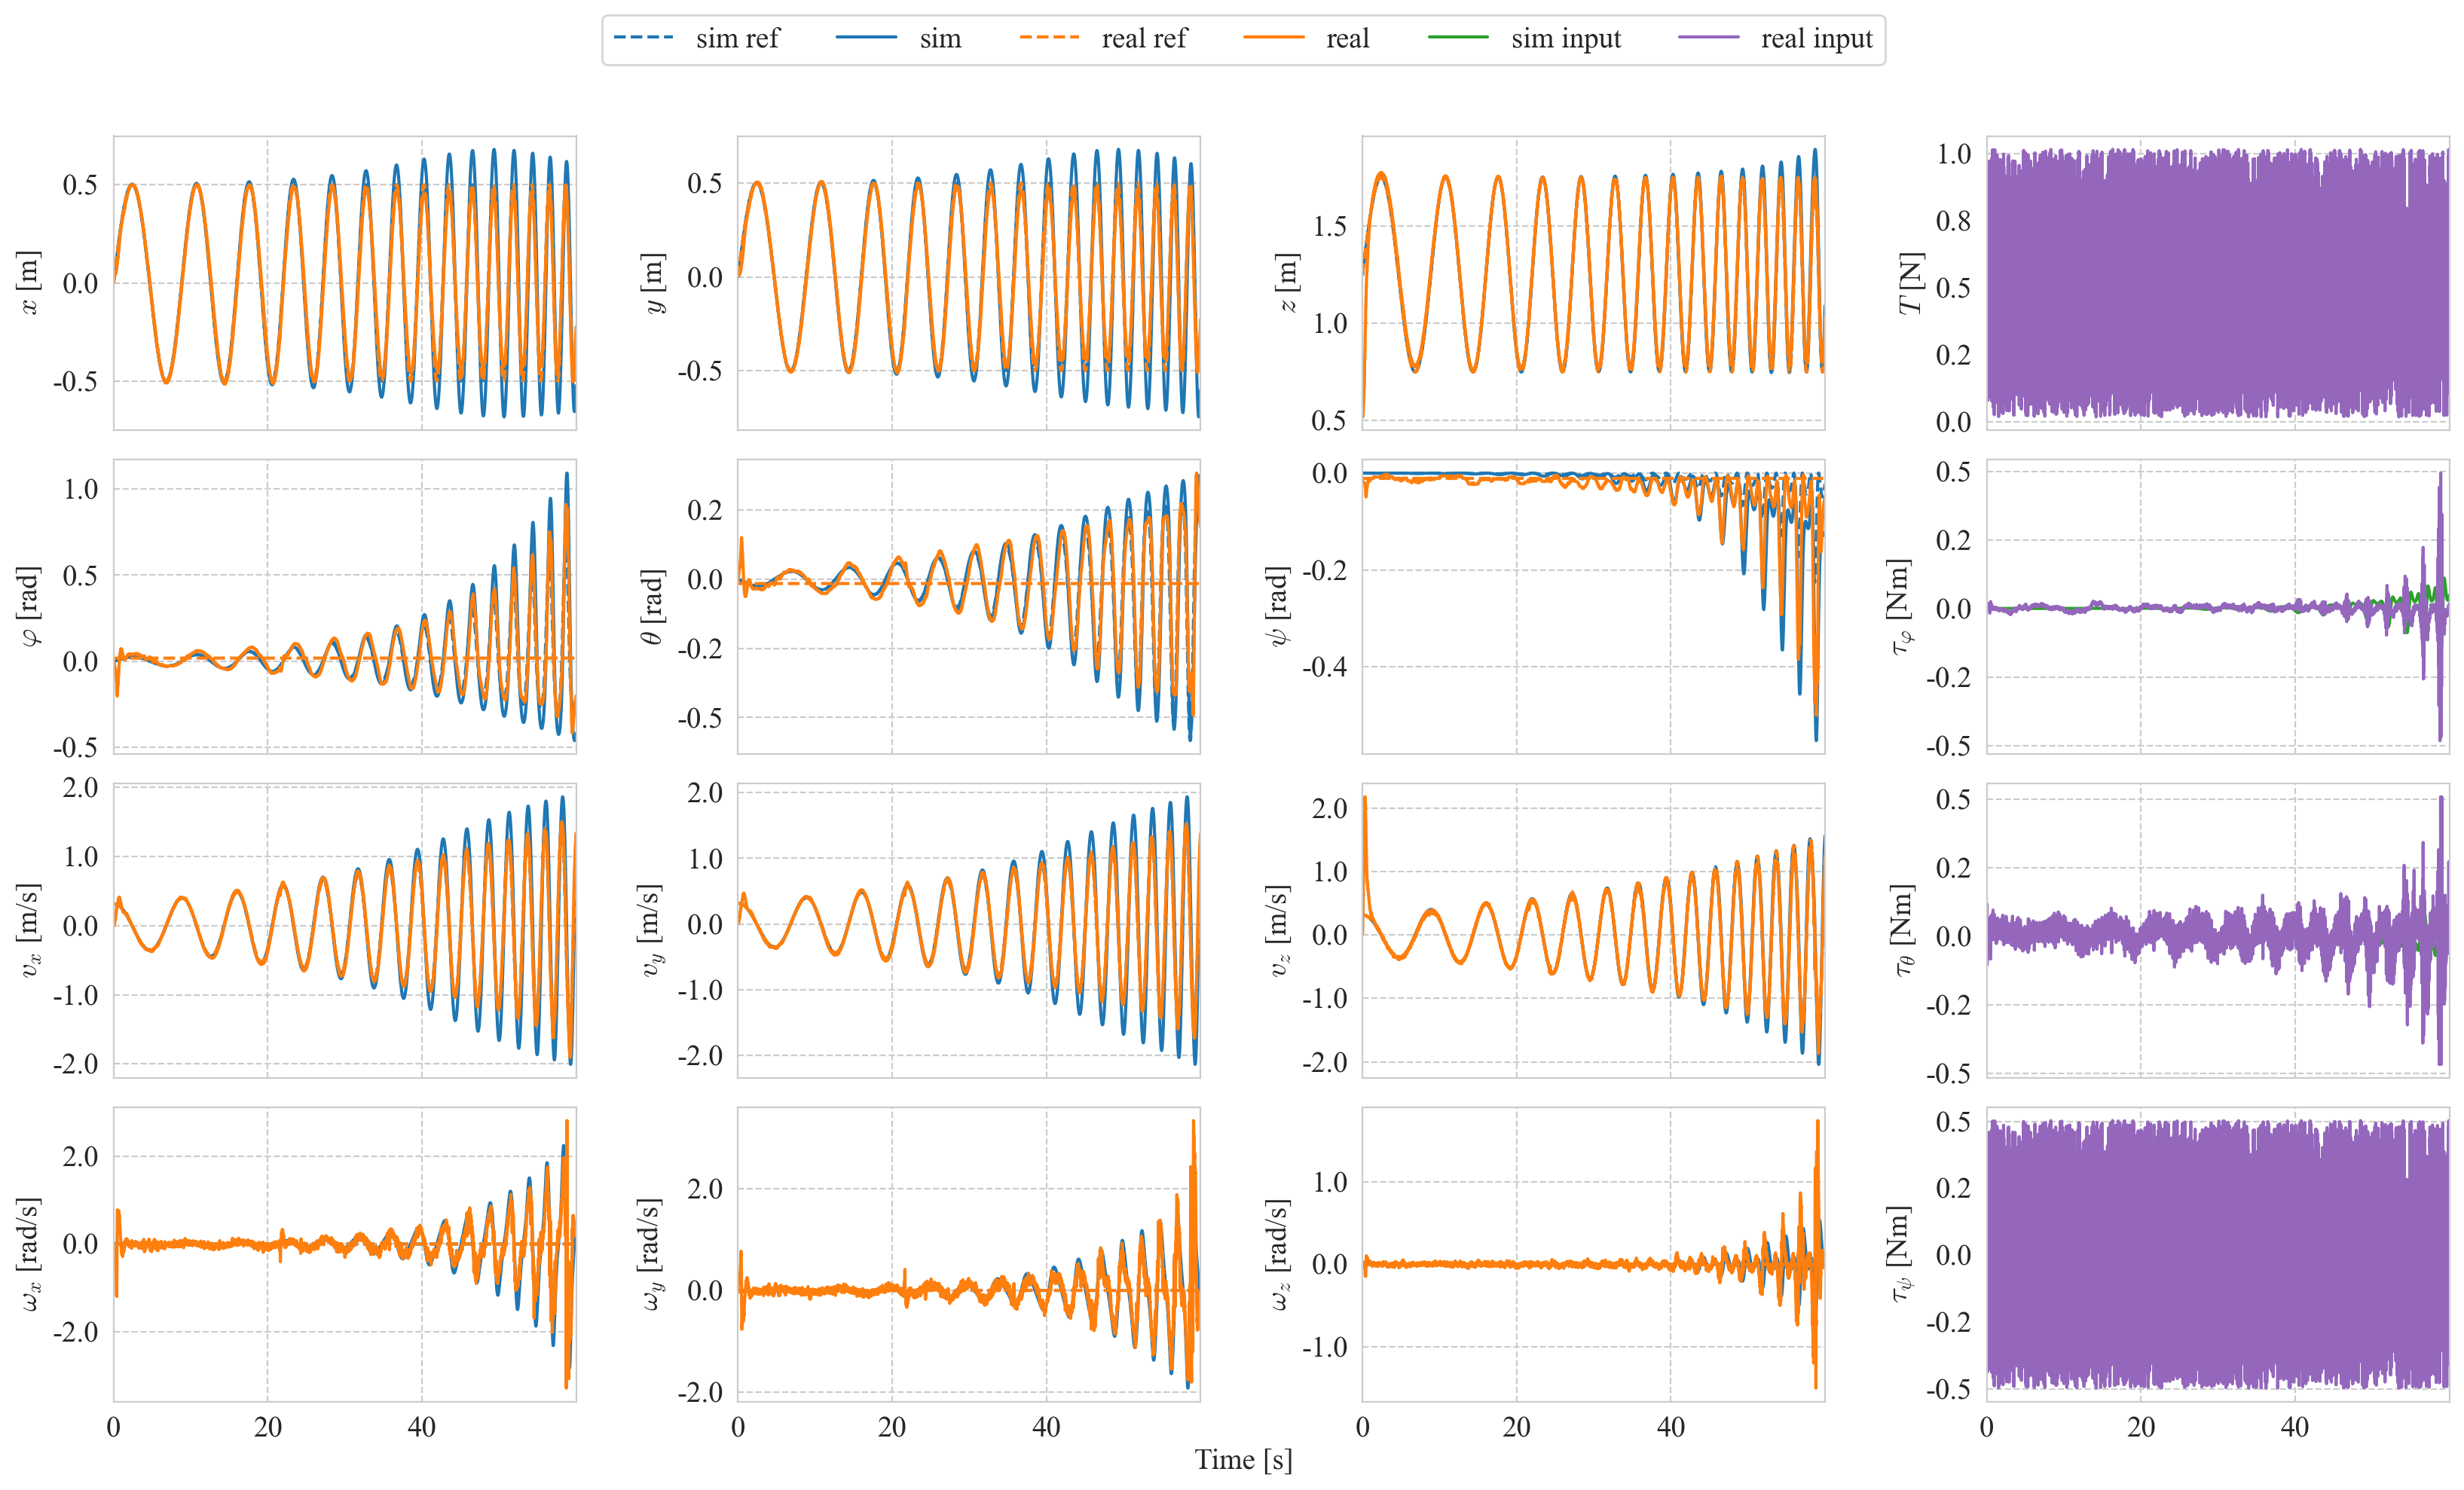

In [152]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# --- Create 4x4 layout ---
fig, axs = plt.subplots(4, 4, figsize=(20, 10), sharex=True, dpi=200)

# --- Define state variables (fill first 3 columns) ---
state_cols = [
    ['x', 'y', 'z'],
    ['roll', 'pitch', 'yaw'],
    ['vx', 'vy', 'vz'],
    ['wx', 'wy', 'wz']
]
state_labels = [
    ['$x$ [m]', '$y$ [m]', '$z$ [m]'],
    [r'$\varphi$ [rad]', r'$\theta$ [rad]', r'$\psi$ [rad]'],
    [r'$v_x$ [m/s]', '$v_y$ [m/s]', '$v_z$ [m/s]'],
    [r'$\omega_x$ [rad/s]', r'$\omega_y$ [rad/s]', r'$\omega_z$ [rad/s]']
]

# --- Inputs (last column) ---
input_cols = ['thrust', 'torque_roll', 'torque_pitch', 'torque_yaw']
input_labels = ['$T$ [N]', r'$\tau_{\varphi}$ [Nm]', r'$\tau_{\theta}$ [Nm]', r'$\tau_{\psi}$ [Nm]']

# --- Plot states ---
for r in range(4):          # rows
    for c in range(3):      # first three columns for states
        col = state_cols[r][c]
        ax = axs[r, c]

        # sim vs ref
        if f'{col}_r' in df_sim.columns:
            ax.plot(t_vec, df_sim[f'{col}_r'], color='tab:blue', linestyle="--", label="sim ref")
        ax.plot(t_vec, df_sim[col], color='tab:blue', label="sim")

        # real vs ref
        if f'{col}_r' in df_real_aligned.columns:
            ax.plot(df_real_aligned['t'], df_real_aligned[f'{col}_r'], color='tab:orange', linestyle="--", label="real ref")
        ax.plot(df_real_aligned['t'], df_real_aligned[col], color='tab:orange', label="real")

        ax.set_ylabel(state_labels[r][c])
        ax.grid(True)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# --- Plot inputs (last column) ---
for r in range(4):
    col = input_cols[r]
    ax = axs[r, 3]

    if col in df_sim.columns:
        ax.plot(t_vec, df_sim[col], color='tab:green', label="sim input")
    if col in df_real_aligned.columns:
        ax.plot(t_vec, df_real_aligned[col], color='tab:purple', label="real input")

    ax.set_ylabel(input_labels[r])
    ax.grid(True)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# --- Shared X label ---
fig.text(0.5, 0.04, "Time [s]", ha='center', va='center', fontsize=14)

# --- Collect all unique legend entries across all subplots ---
handles, labels = [], []
for ax in axs.flat:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:  # avoid duplicates
            handles.append(handle)
            labels.append(label)

# --- Combined legend for all (including inputs) ---
fig.legend(handles, labels, loc='upper center', ncols=6, bbox_to_anchor=(0.5, 1.01))

# --- Layout tweaks ---
plt.subplots_adjust(top=0.92, bottom=0.08, hspace=0.1, wspace=0.35)
plt.show()


<Axes: >

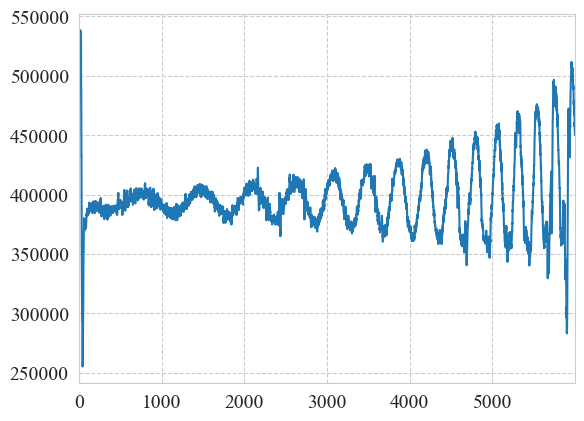

In [153]:
df_real_aligned[['m1_erpm', 'm2_erpm', 'm3_erpm', 'm4_erpm']].sum(axis=1).plot()

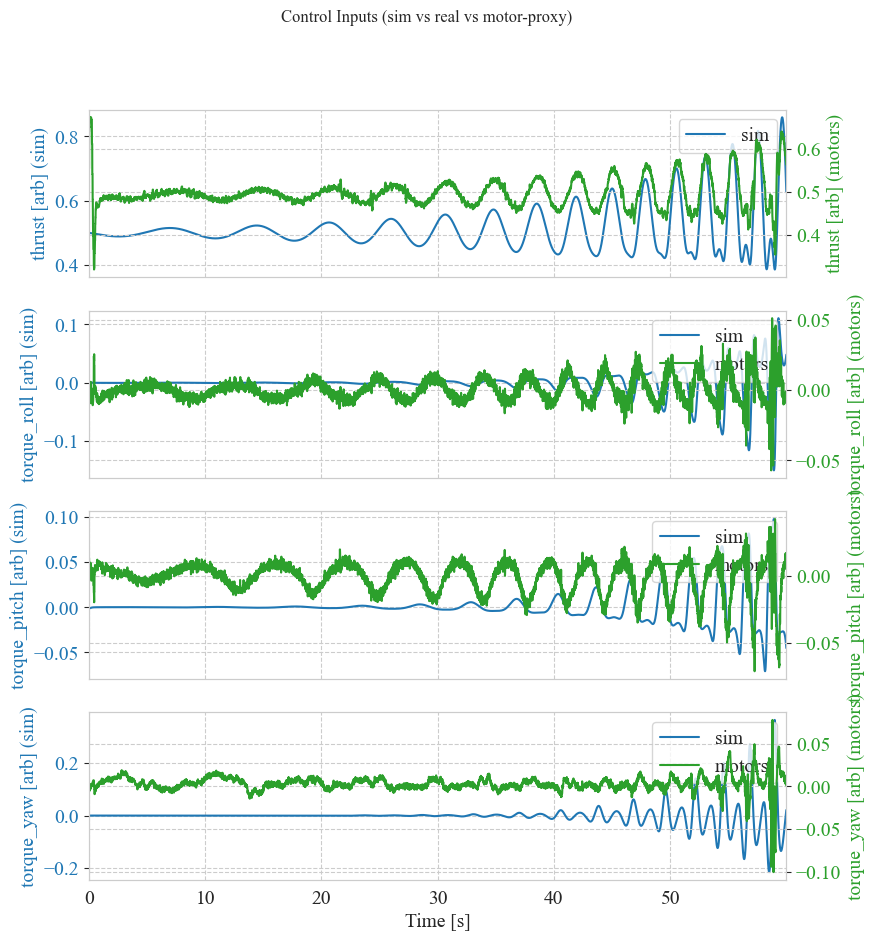

In [154]:
# --- Compute motor-based proxies ---
thrust_motors = df_real_aligned[['m1_erpm', 'm2_erpm', 'm3_erpm', 'm4_erpm']].sum(axis=1)

# torque roll ~ (right motors) - (left motors)
tau_x_motors = df_real_aligned[['m3_erpm', 'm4_erpm']].sum(axis=1) - df_real_aligned[['m1_erpm', 'm2_erpm']].sum(axis=1)

# torque pitch ~ (front motors) - (rear motors)
tau_y_motors = df_real_aligned[['m2_erpm', 'm3_erpm']].sum(axis=1) - df_real_aligned[['m1_erpm', 'm4_erpm']].sum(axis=1)

# torque yaw ~ (CW motors) - (CCW motors)   (depending on config, adjust signs)
tau_z_motors = df_real_aligned[['m1_erpm', 'm3_erpm']].sum(axis=1) - df_real_aligned[['m2_erpm', 'm4_erpm']].sum(axis=1)

df_real_motors = pd.DataFrame({
    'thrust': thrust_motors,
    'torque_roll': tau_x_motors,
    'torque_pitch': tau_y_motors,
    'torque_yaw': tau_z_motors,
}) / 8e5

# --- Control Inputs ---
fig, axs = plt.subplots(4, 1, figsize=(9, 10), sharex=True)
labels = ["thrust [arb]", "torque_roll [arb]", "torque_pitch [arb]", "torque_yaw [arb]"]

for i, col in enumerate(['thrust', 'torque_roll', 'torque_pitch', 'torque_yaw']):
    ax = axs[i]

    # Create a twin y-axis
    ax2 = ax.twinx()

    # Plot simulated data on left y-axis
    ax.plot(t_vec, df_sim[col], color="tab:blue", label="sim")

    # Plot real motor data on right y-axis
    ax2.plot(t_vec, df_real_motors[col], color="tab:green", label="motors")

    # Labels and grid
    ax.set_ylabel(f"{labels[i]} (sim)", color="tab:blue")
    ax2.set_ylabel(f"{labels[i]} (motors)", color="tab:green")

    ax.tick_params(axis='y', labelcolor="tab:blue")
    ax2.tick_params(axis='y', labelcolor="tab:green")
    ax.grid(True)


    # Optional: combine legends
    lines, labels_ = ax.get_legend_handles_labels()
    lines2, labels2_ = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels_ + labels2_, loc="upper right")


axs[-1].set_xlabel("Time [s]")
axs[0].legend(loc="upper right")
fig.suptitle("Control Inputs (sim vs real vs motor-proxy)")
plt.show()
